In [1]:
import pandas as pd

df = pd.read_csv("fertilizer_dataset.csv")
print(df.head())

   Temperature  Humidity Soil_Type Crop_Type   N   P   K Fertilizer
0           26        81     Sandy   Cassava  71  60  20        NPK
1           26        87      Clay   Cassava  74  74  87    Compost
2           23        69      Clay      Rice  52   1  87        DAP
3           31        59     Loamy      Rice  63  59  20        NPK
4           20        41     Loamy      Rice  88  48  90    Compost


In [2]:
import pandas as pd

df = pd.read_csv("fertilizer_dataset.csv")

print(df.head())
print(df.shape)

   Temperature  Humidity Soil_Type Crop_Type   N   P   K Fertilizer
0           26        81     Sandy   Cassava  71  60  20        NPK
1           26        87      Clay   Cassava  74  74  87    Compost
2           23        69      Clay      Rice  52   1  87        DAP
3           31        59     Loamy      Rice  63  59  20        NPK
4           20        41     Loamy      Rice  88  48  90    Compost
(2000, 8)


In [3]:
print(df.isnull().sum())

Temperature    0
Humidity       0
Soil_Type      0
Crop_Type      0
N              0
P              0
K              0
Fertilizer     0
dtype: int64


In [4]:
df = df.dropna()

In [5]:
print(df.dtypes)

Temperature    int64
Humidity       int64
Soil_Type        str
Crop_Type        str
N              int64
P              int64
K              int64
Fertilizer       str
dtype: object


In [6]:
print(df["Fertilizer"].value_counts())

Fertilizer
Compost    681
Urea       605
DAP        424
NPK        290
Name: count, dtype: int64


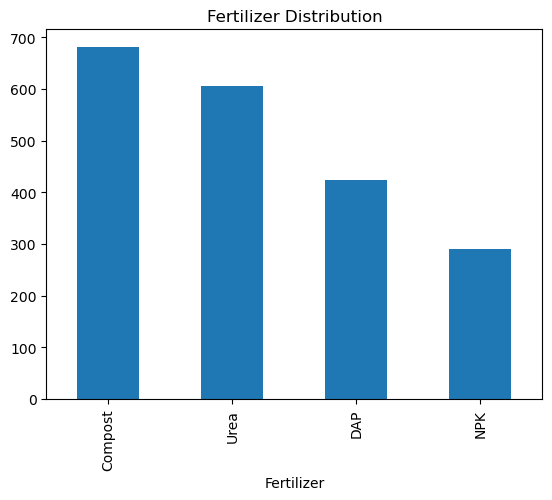

In [7]:
import matplotlib.pyplot as plt

df["Fertilizer"].value_counts().plot(kind="bar")
plt.title("Fertilizer Distribution")
plt.show()

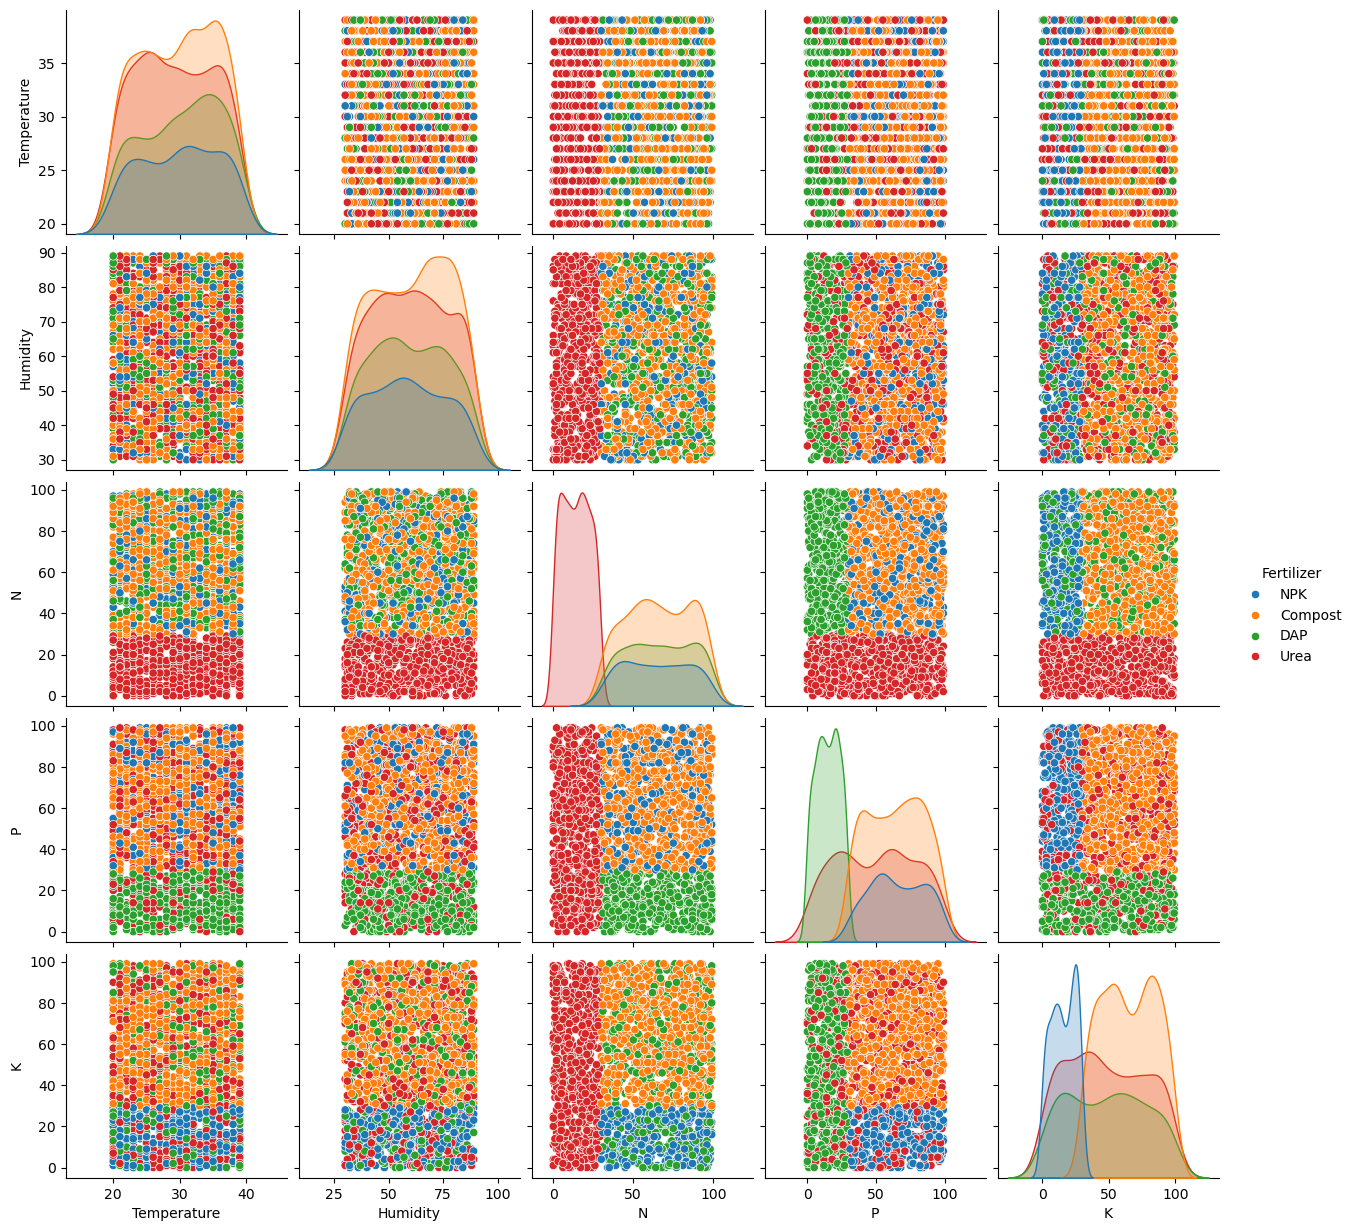

In [8]:
import seaborn as sns

sns.pairplot(df, hue="Fertilizer")
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fert = LabelEncoder()

In [10]:
df["Soil_Type"] = le_soil.fit_transform(df["Soil_Type"])
df["Crop_Type"] = le_crop.fit_transform(df["Crop_Type"])
df["Fertilizer"] = le_fert.fit_transform(df["Fertilizer"])

In [11]:
print(le_soil.classes_)
print(le_crop.classes_)
print(le_fert.classes_)

['Clay' 'Loamy' 'Sandy']
['Cassava' 'Maize' 'Rice' 'Wheat']
['Compost' 'DAP' 'NPK' 'Urea']


In [12]:
import joblib

joblib.dump(le_soil, "soil_encoder.pkl")
joblib.dump(le_crop, "crop_encoder.pkl")
joblib.dump(le_fert, "fert_encoder.pkl")

['fert_encoder.pkl']

In [13]:
#slit
X = df.drop("Fertilizer", axis=1)
y = df["Fertilizer"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       137
           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00        50
           3       1.00      1.00      1.00       129

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [18]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

N              0.444975
P              0.300049
K              0.209684
Humidity       0.019085
Temperature    0.014692
Crop_Type      0.006158
Soil_Type      0.005356
dtype: float64


In [19]:
import joblib

joblib.dump(model, "fertilizer_model.pkl")

['fertilizer_model.pkl']

In [20]:
pip install streamlit

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.1 MB 4.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.4/9.1 MB 8.2 MB/s eta 0:00:01
   --------------------------- ------------ 6.3/9.1 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 10.8 MB/s  0:00:01
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 795.4/795.4 kB 12.3 MB/s  0:00:00
   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   ---------------- ----------------------- 2.9/6.9 MB 36.3 MB/s eta 0:00:01
   ------------------------------- -------- 5.5/6.9 MB 17.1 MB/s eta 0:00:01
   ---------------------------------------- 6.9/6.9 MB 14.9 MB/s  0:00:00
   ---------------------------------------- 0.0/28.2 MB ? eta -:--:--
   --- ------------------------------------

In [23]:
app.py

NameError: name 'app' is not defined